In [1]:
%load_ext autoreload
%autoreload 2

import matplotlib.pyplot as plt
import sys
sys.path.append('../')
from utils import get_train_results, add_scatterplot, add_history_plot
from scipy import stats

plt.rcParams["text.usetex"] = False

import warnings
warnings.filterwarnings('ignore')

model_name = 'cnn'

## Load data

In [2]:
y_test_k01, predictions_k01, history_k01 = get_train_results(model_name, "k0.1")
y_test_k05, predictions_k05, history_k05 = get_train_results(model_name, "k0.5")
y_test_k5, predictions_k5, history_k5 = get_train_results(model_name, "k5.0")
y_test_k10, predictions_k10, history_k10 = get_train_results(model_name, "k10.0")

In [3]:
import numpy as np 
def mean_absolute_percentage_error(y_true, y_pred): 
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100


v1 = mean_absolute_percentage_error(y_test_k01, predictions_k01)
v2 = mean_absolute_percentage_error(y_test_k05, predictions_k05)
v3 = mean_absolute_percentage_error(y_test_k5, predictions_k5)
v4 = mean_absolute_percentage_error(y_test_k10, predictions_k10)
print(v1,v2,v3,v4)

0.042693392561739214 0.10809425822490909 0.014798798560708109 0.01724158811233532


In [4]:
np.mean([
    0.04156607347571564, 0.03114003950280738, 0.015544841853600702, 0.016587675112595183,
    0.009386191407651344, 0.024290225414914417, 0.022862156513028455, 0.014374463489331298,
    0.16425229593053242, 0.03346757547706488, 0.011953283444444277, 0.013843209064934591,    
    0.17812573575550783, 0.920486608728023])

0.10699145536929654

# Plot

k=0.1: pearson coefs= 0.9999973669158457
k=0.5: pearson coefs= 0.9999989562282879
k=5.0: pearson coefs= 0.9999992606226236
k=10.0: pearson coefs= 0.9999990933636227


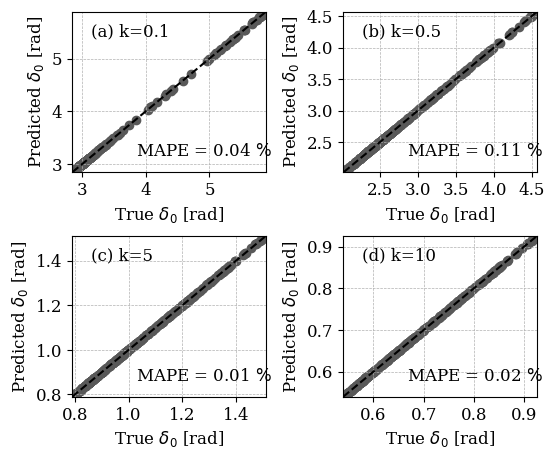

In [5]:
fig, axs = plt.subplots(2, 2, figsize=(6, 5))

print('k=0.1: pearson coefs=', stats.pearsonr(y_test_k01, predictions_k01)[0])
add_scatterplot(axs, (0, 0), y_test_k01, predictions_k01, str_label='(a) k=0.1', nticks=6)

print('k=0.5: pearson coefs=', stats.pearsonr(y_test_k05, predictions_k05)[0])
add_scatterplot(axs, (0, 1), y_test_k05, predictions_k05, str_label='(b) k=0.5', nticks=6)

print('k=5.0: pearson coefs=', stats.pearsonr(y_test_k5, predictions_k5)[0])
add_scatterplot(axs, (1, 0), y_test_k5, predictions_k5, str_label='(c) k=5', nticks=6)

print('k=10.0: pearson coefs=', stats.pearsonr(y_test_k10, predictions_k10)[0])
add_scatterplot(axs, (1, 1), y_test_k10, predictions_k10, str_label='(d) k=10', nticks=6)

#plt.tight_layout()
plt.subplots_adjust(left=None, bottom=None, right=None, top=None, wspace=0.4, hspace=0.4)
plt.savefig('output/'+model_name+'/yukawa_scatter.pdf', format='pdf')
plt.show()

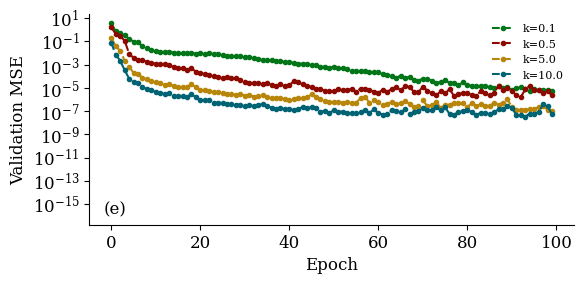

In [6]:
plt.style.use('seaborn-dark-palette') 
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']  

fig, ax = plt.subplots(figsize=(6, 3))
#plt.axes(yscale='log')

ax.plot(history_k01['loss'], label='k=0.1', marker='.', linestyle='dashed', color=colors[1])
ax.plot(history_k05['loss'], label='k=0.5', marker='.', linestyle='dashed', color=colors[2])
ax.plot(history_k5['loss'], label='k=5.0', marker='.', linestyle='dashed', color=colors[4])
ax.plot(history_k10['loss'], label='k=10.0', marker='.', linestyle='dashed', color=colors[5])

#ax2 = fig.add_axes([0.4, 0.5, 0.35, 0.3])
#ax2.plot(history_k01['loss'], label='k=0.1', marker='.', linestyle='dashed', color=colors[1])
#ax2.plot(history_k05['loss'], label='k=0.5', marker='.', linestyle='dashed', color=colors[2])
#ax2.plot(history_k5['loss'], label='k=5.0', marker='.', linestyle='dashed', color=colors[4])
#ax2.plot(history_k10['loss'], label='k=10.0', marker='.', linestyle='dashed', color=colors[5])
#ax2.set_xlim(0, 3)
#ax2.set_ylim(0, 0.05)
#ax2.axhline(y=0, color='grey', linestyle='--', linewidth=0.8)
#ax2.set_ylabel('MSE')
#ax2.set_xlabel('Epoch')

ax.set_ylabel('Validation MSE')
ax.set_xlabel('Epoch')
ax.legend(loc='upper right', frameon=False)
ax.axhline(y=0, color='grey', linestyle='--', linewidth=0.8)

ax.set_yscale('log')
import matplotlib 
import numpy 
y_major = matplotlib.ticker.LogLocator(base=10.0, numticks=10)
ax.yaxis.set_major_locator(y_major)
y_minor = matplotlib.ticker.LogLocator(base=10.0, subs=numpy.arange(1.0, 10.0) * 0.1, numticks=10)
ax.yaxis.set_minor_locator(y_minor)
ax.yaxis.set_minor_formatter(matplotlib.ticker.NullFormatter())

for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)

# ax.set_ylim(0, 2)

ax.text(0.03, 0.05, '(e)', transform=ax.transAxes, size=12)

plt.tight_layout()
plt.grid(False)
plt.savefig('output/'+model_name+'/yukawa_history_log.pdf', format='pdf')
plt.show()


In [7]:
model_name = 'rnn'

In [8]:
y_test_k01, predictions_k01, history_k01 = get_train_results(model_name, "k0.1")
y_test_k05, predictions_k05, history_k05 = get_train_results(model_name, "k0.5")
y_test_k5, predictions_k5, history_k5 = get_train_results(model_name, "k5.0")
y_test_k10, predictions_k10, history_k10 = get_train_results(model_name, "k10.0")

FileNotFoundError: [Errno 2] No such file or directory: 'output/rnn/predictions_k0.1.npy'

In [ ]:
import numpy as np 
def mean_absolute_percentage_error(y_true, y_pred): 
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100


v1 = mean_absolute_percentage_error(y_test_k01, predictions_k01)
v2 = mean_absolute_percentage_error(y_test_k05, predictions_k05)
v3 = mean_absolute_percentage_error(y_test_k5, predictions_k5)
v4 = mean_absolute_percentage_error(y_test_k10, predictions_k10)
print(v1,v2,v3,v4)

0.042693392561739214 0.10809425822490909 0.014798798560708109 0.01724158811233532


In [ ]:
np.mean([
    0.04156607347571564, 0.03114003950280738, 0.015544841853600702, 0.016587675112595183,
    0.009386191407651344, 0.024290225414914417, 0.022862156513028455, 0.014374463489331298,
    0.16425229593053242, 0.03346757547706488, 0.011953283444444277, 0.013843209064934591,    
    0.17812573575550783, 0.920486608728023])

0.10699145536929654

# Plot

k=0.1: pearson coefs= 0.9999973669158457
k=0.5: pearson coefs= 0.9999989562282879
k=5.0: pearson coefs= 0.9999992606226236
k=10.0: pearson coefs= 0.9999990933636227


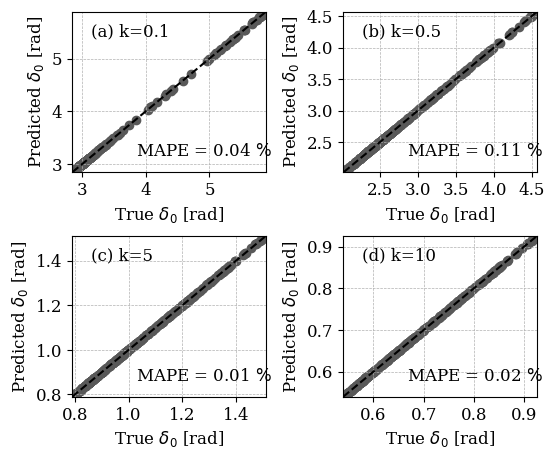

In [ ]:
fig, axs = plt.subplots(2, 2, figsize=(6, 5))

print('k=0.1: pearson coefs=', stats.pearsonr(y_test_k01, predictions_k01)[0])
add_scatterplot(axs, (0, 0), y_test_k01, predictions_k01, str_label='(a) k=0.1', nticks=6)

print('k=0.5: pearson coefs=', stats.pearsonr(y_test_k05, predictions_k05)[0])
add_scatterplot(axs, (0, 1), y_test_k05, predictions_k05, str_label='(b) k=0.5', nticks=6)

print('k=5.0: pearson coefs=', stats.pearsonr(y_test_k5, predictions_k5)[0])
add_scatterplot(axs, (1, 0), y_test_k5, predictions_k5, str_label='(c) k=5', nticks=6)

print('k=10.0: pearson coefs=', stats.pearsonr(y_test_k10, predictions_k10)[0])
add_scatterplot(axs, (1, 1), y_test_k10, predictions_k10, str_label='(d) k=10', nticks=6)

#plt.tight_layout()
plt.subplots_adjust(left=None, bottom=None, right=None, top=None, wspace=0.4, hspace=0.4)
plt.savefig('output/'+model_name+'/yukawa_scatter.pdf', format='pdf')
plt.show()

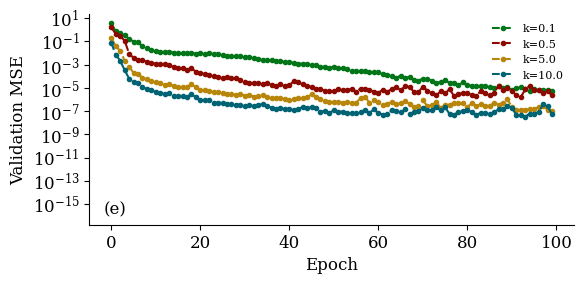

In [ ]:
plt.style.use('seaborn-dark-palette') 
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']  

fig, ax = plt.subplots(figsize=(6, 3))
#plt.axes(yscale='log')

ax.plot(history_k01['loss'], label='k=0.1', marker='.', linestyle='dashed', color=colors[1])
ax.plot(history_k05['loss'], label='k=0.5', marker='.', linestyle='dashed', color=colors[2])
ax.plot(history_k5['loss'], label='k=5.0', marker='.', linestyle='dashed', color=colors[4])
ax.plot(history_k10['loss'], label='k=10.0', marker='.', linestyle='dashed', color=colors[5])

#ax2 = fig.add_axes([0.4, 0.5, 0.35, 0.3])
#ax2.plot(history_k01['loss'], label='k=0.1', marker='.', linestyle='dashed', color=colors[1])
#ax2.plot(history_k05['loss'], label='k=0.5', marker='.', linestyle='dashed', color=colors[2])
#ax2.plot(history_k5['loss'], label='k=5.0', marker='.', linestyle='dashed', color=colors[4])
#ax2.plot(history_k10['loss'], label='k=10.0', marker='.', linestyle='dashed', color=colors[5])
#ax2.set_xlim(0, 3)
#ax2.set_ylim(0, 0.05)
#ax2.axhline(y=0, color='grey', linestyle='--', linewidth=0.8)
#ax2.set_ylabel('MSE')
#ax2.set_xlabel('Epoch')

ax.set_ylabel('Validation MSE')
ax.set_xlabel('Epoch')
ax.legend(loc='upper right', frameon=False)
ax.axhline(y=0, color='grey', linestyle='--', linewidth=0.8)

ax.set_yscale('log')
import matplotlib 
import numpy 
y_major = matplotlib.ticker.LogLocator(base=10.0, numticks=10)
ax.yaxis.set_major_locator(y_major)
y_minor = matplotlib.ticker.LogLocator(base=10.0, subs=numpy.arange(1.0, 10.0) * 0.1, numticks=10)
ax.yaxis.set_minor_locator(y_minor)
ax.yaxis.set_minor_formatter(matplotlib.ticker.NullFormatter())

for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)

# ax.set_ylim(0, 2)

ax.text(0.03, 0.05, '(e)', transform=ax.transAxes, size=12)

plt.tight_layout()
plt.grid(False)
plt.savefig('output/'+model_name+'/yukawa_history_log.pdf', format='pdf')
plt.show()
